In [1]:
!pip install timm -q

In [2]:
# =========================
# 1. IMPORTS
# =========================
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
import timm
from torch.utils.data import DataLoader, Subset

import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
import timm
print(timm.list_models("*efficientnet*"))

['efficientnet_b0', 'efficientnet_b0_g8_gn', 'efficientnet_b0_g16_evos', 'efficientnet_b0_gn', 'efficientnet_b1', 'efficientnet_b1_pruned', 'efficientnet_b2', 'efficientnet_b2_pruned', 'efficientnet_b3', 'efficientnet_b3_g8_gn', 'efficientnet_b3_gn', 'efficientnet_b3_pruned', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_b8', 'efficientnet_blur_b0', 'efficientnet_cc_b0_4e', 'efficientnet_cc_b0_8e', 'efficientnet_cc_b1_8e', 'efficientnet_el', 'efficientnet_el_pruned', 'efficientnet_em', 'efficientnet_es', 'efficientnet_es_pruned', 'efficientnet_h_b5', 'efficientnet_l2', 'efficientnet_lite0', 'efficientnet_lite1', 'efficientnet_lite2', 'efficientnet_lite3', 'efficientnet_lite4', 'efficientnet_x_b3', 'efficientnet_x_b5', 'efficientnetv2_l', 'efficientnetv2_m', 'efficientnetv2_rw_m', 'efficientnetv2_rw_s', 'efficientnetv2_rw_t', 'efficientnetv2_s', 'efficientnetv2_xl', 'gc_efficientnetv2_rw_t', 'test_efficientnet', 'test_efficientnet_evos', 'test

In [4]:
# =========================
# 2. DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
# =========================
# 3. DATA PATH
# =========================
data_dir = "/kaggle/input/datasets/nayemsiddiki/skindiseasebd/SkinDiseaseBD A Dataset of Common Skin Disease Ima/Updated Images"

In [6]:
# =========================
# 4. TRANSFORMS
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [7]:
# =========================
# 5. LOAD DATASET
# =========================
full_dataset = datasets.ImageFolder(root=data_dir)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

# =========================
# SPLIT: TRAIN / VAL / TEST
# =========================
indices = np.arange(len(full_dataset))
np.random.shuffle(indices)

train_split = int(0.7 * len(indices))
val_split   = int(0.85 * len(indices))  # 70 + 15

train_idx = indices[:train_split]
val_idx   = indices[train_split:val_split]
test_idx  = indices[val_split:]

# Datasets with transforms
train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=data_dir, transform=val_transforms)
test_dataset  = datasets.ImageFolder(root=data_dir, transform=val_transforms)

# Subsets
train_dataset = Subset(train_dataset, train_idx)
val_dataset   = Subset(val_dataset, val_idx)
test_dataset  = Subset(test_dataset, test_idx)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

Classes: ['Dermatitis', 'Eczema', 'Scabies', 'Tinea Ringworm', 'Vitiligo']


In [8]:
# =========================
# 6. MODEL (EfficientNetV2-B0 using timm)
# =========================
model = timm.create_model(
    "tf_efficientnetv2_b0",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

In [9]:
# =========================
# 7. LOSS & OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [10]:
# =========================
# 8. TRAIN FUNCTION
# =========================
def train_model(model, train_loader, val_loader, epochs):
    history = {
        "train_loss": [],
        "val_loss": [],   # ✅ NEW
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # ===== VALIDATION =====
        model.eval()
        val_loss_total = 0   # ✅ NEW
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)   # ✅ NEW

                val_loss_total += loss.item()       # ✅ NEW

                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_total / len(val_loader)   # ✅ NEW
        val_acc = val_correct / val_total

        # Save history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)   # ✅ NEW
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [11]:
# =========================
# 9. EVALUATION
# =========================
def evaluate_model(model, loader, class_names, name="TEST"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"\n===== {name} METRICS =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    return cm

In [12]:
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    # ===== LOSS CURVE =====
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")  # ✅ NEW
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

    # ===== ACCURACY CURVE =====
    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.show()


Epoch [1/35]
Train Loss: 2.0771 | Val Loss: 1.7084
Train Acc: 0.3138 | Val Acc: 0.3926

Epoch [2/35]
Train Loss: 1.3176 | Val Loss: 1.1861
Train Acc: 0.5133 | Val Acc: 0.5785

Epoch [3/35]
Train Loss: 0.9196 | Val Loss: 0.8816
Train Acc: 0.6480 | Val Acc: 0.6694

Epoch [4/35]
Train Loss: 0.6731 | Val Loss: 0.6916
Train Acc: 0.7553 | Val Acc: 0.7273

Epoch [5/35]
Train Loss: 0.5391 | Val Loss: 0.5419
Train Acc: 0.8076 | Val Acc: 0.7645

Epoch [6/35]
Train Loss: 0.4214 | Val Loss: 0.4385
Train Acc: 0.8537 | Val Acc: 0.8182

Epoch [7/35]
Train Loss: 0.3580 | Val Loss: 0.3694
Train Acc: 0.8839 | Val Acc: 0.8554

Epoch [8/35]
Train Loss: 0.2785 | Val Loss: 0.2882
Train Acc: 0.9096 | Val Acc: 0.9008

Epoch [9/35]
Train Loss: 0.2662 | Val Loss: 0.2685
Train Acc: 0.9069 | Val Acc: 0.9091

Epoch [10/35]
Train Loss: 0.2596 | Val Loss: 0.2350
Train Acc: 0.9211 | Val Acc: 0.9298

Epoch [11/35]
Train Loss: 0.1875 | Val Loss: 0.1844
Train Acc: 0.9477 | Val Acc: 0.9463

Epoch [12/35]
Train Loss: 0.2

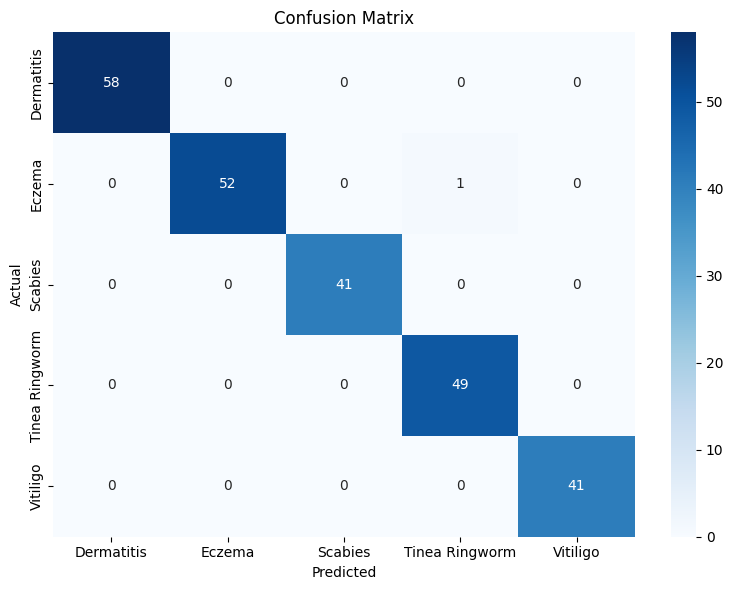


===== TEST METRICS =====
Accuracy : 0.9876
Precision: 0.9880
Recall   : 0.9876
F1 Score : 0.9876

Classification Report:
                precision    recall  f1-score   support

    Dermatitis       0.97      1.00      0.98        32
        Eczema       0.97      1.00      0.98        63
       Scabies       1.00      0.95      0.98        43
Tinea Ringworm       1.00      0.98      0.99        60
      Vitiligo       1.00      1.00      1.00        44

      accuracy                           0.99       242
     macro avg       0.99      0.99      0.99       242
  weighted avg       0.99      0.99      0.99       242



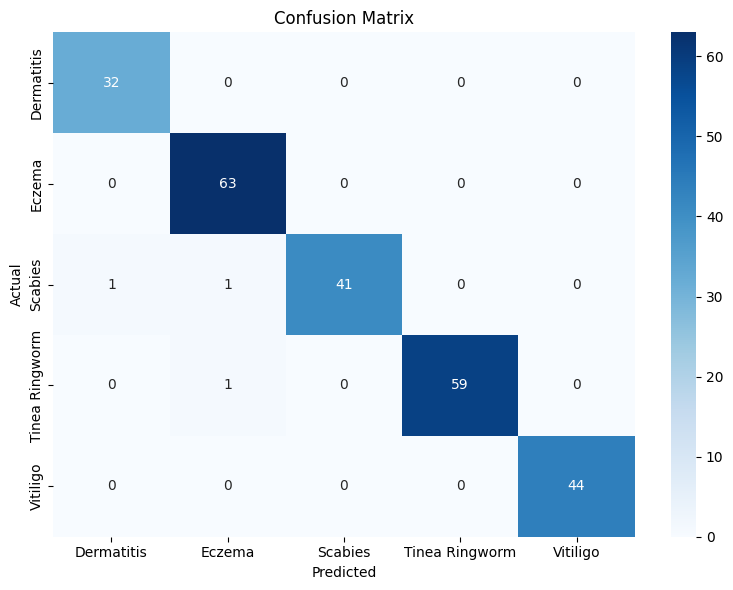

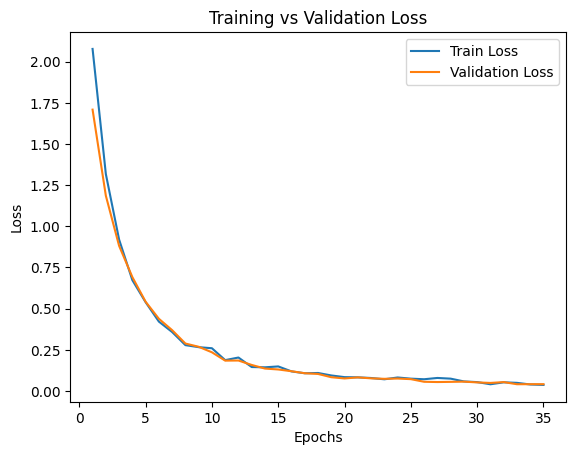

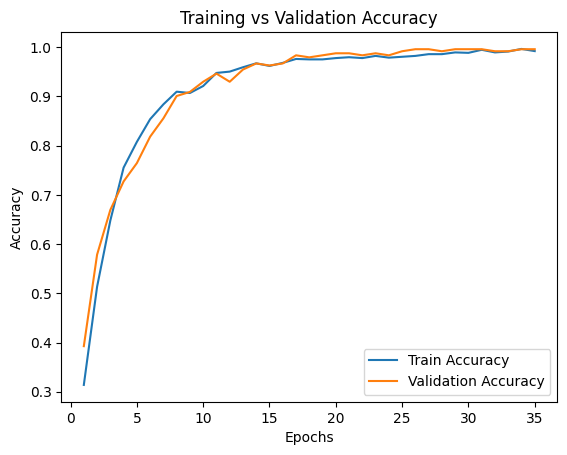

In [13]:
# =========================
# TRAIN
# =========================
history = train_model(model, train_loader, val_loader, epochs=35)

# =========================
# VALIDATION (optional check)
# =========================
cm_val = evaluate_model(model, val_loader, class_names, name="VALIDATION")
plot_confusion_matrix(cm_val, class_names)

# =========================
# FINAL TEST (REAL RESULT)
# =========================
cm_test = evaluate_model(model, test_loader, class_names, name="TEST")
plot_confusion_matrix(cm_test, class_names)

# =========================
# CURVES
# =========================
plot_training_curves(history)

In [14]:
# =========================
# 12. SAVE MODEL
# =========================
torch.save(model.state_dict(), "ekaggfficientnetv2_skin.pth")

In [15]:
import os

print("Original model size:", os.path.getsize("ekaggfficientnetv2_skin.pth")/1e6, "MB")

Original model size: 23.858327 MB


In [16]:
import time

model.eval()

input_tensor = torch.randn(1,3,224,224).to(device)

start = time.time()
model(input_tensor)
end = time.time()

print("Inference time:", end - start, "seconds")

Inference time: 0.10680341720581055 seconds
